## Imports

In [1]:
import requests
import pprint

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Client ID

In [2]:
with open(r'C:\Users\stige\Proton Drive\stigep\My files\Data science 2 årig\brukerinfo_meteorologisk.txt', 'r') as f:
    for line in f:
        if line.startswith("Client ID:"):
            client_id = line.split(":")[1].strip()
        else:
            break

## Task 1

## Retrieving data from Meteorologisk Institutt

In [3]:
# Define endpoint and parameters
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31',
}

# Issue an HTTP GET request
r = requests.get(endpoint, parameters, auth=(client_id,''))
# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json['data']
    print('Data retrieved from frost.met.no!')
else:
    print('Error! Returned status code %s' % r.status_code)
    print('Message: %s' % json['error']['message'])
    print('Reason: %s' % json['error']['reason'])

Data retrieved from frost.met.no!


In [4]:
# Saving to a Pandas df as describes by:
# https://frost.met.no/python_example.html

# This will return a Dataframe with all of the observations in a table format
table = pd.DataFrame()
for i in range(len(data)):
    row = pd.DataFrame(data[i]['observations'])
    row['referenceTime'] = data[i]['referenceTime']
    row['sourceId'] = data[i]['sourceId']
    table = pd.concat([table, row], ignore_index=True)

# These additional columns will be kept
columns = ['sourceId','referenceTime','elementId','value','unit','timeOffset']
df = table[columns].copy()
# Convert the time value to something Python understands
df['referenceTime'] = pd.to_datetime(df['referenceTime'])


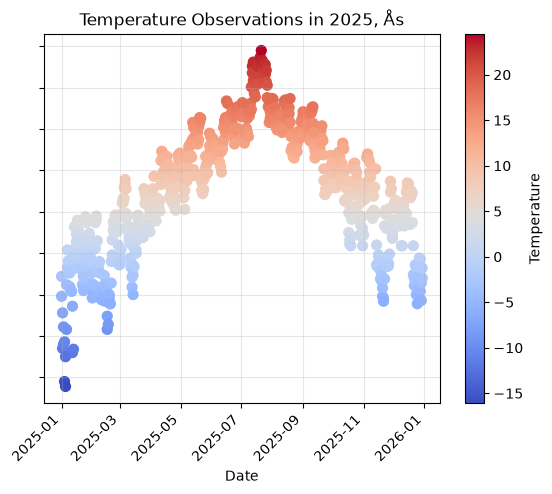

In [8]:
# plt.plot(df['referenceTime'],
#          df['value'],
#          color='gray',
#          alpha=0.5
# )
temp_fig = plt.scatter(df['referenceTime'],
                       df['value'],
                       c=df['value'],
                       cmap='coolwarm',
                       s=50
)

plt.grid(True,
         alpha=0.3,
         which='both'
)
plt.gca().set_yticklabels([])
plt.xticks(rotation=45,
           ha='right'
)
plt.colorbar(temp_fig,
             label='Temperature'
)
plt.xlabel('Date')
plt.title('Temperature Observations in 2025, Ås')
plt.show()
